<a href="https://colab.research.google.com/github/Justine-Lewis/carisurg_portfolio/blob/main/Week5_Final_DataExploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Week 5 Final: AI-Assisted Triage Data Exploration

This notebook profiles the Week 5 ED arrivals dataset for the final submission. It focuses on dataset shape, clinical feature families, missingness, ESI distribution, chief complaint frequencies, demographic distributions, and early plausibility checks.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

DATA_PATH = Path("yaleemmlc_admissionprediction_triage.csv")
DOCS_PATH = Path("../docs")
DOCS_PATH.mkdir(exist_ok=True)


df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)

print(df.shape)
print("Total missing values:", df.isna().sum().sum())
print("Columns with missing values:", (df.isna().sum() > 0).sum())

print("Current folder:", Path.cwd())

for path in Path("/content").rglob("yaleemmlc_admissionprediction_triage.csv"):
    print("Found:", path)
    print("Size MB:", round(path.stat().st_size / (1024 * 1024), 2))

Dataset shape: (55121, 226)
(55121, 226)
Total missing values: 0
Columns with missing values: 0
Current folder: /content
Found: /content/yaleemmlc_admissionprediction_triage.csv
Size MB: 51.98


## 1. Dataset shape and column families

The dataset is expected to be wide because many columns are binary chief complaint flags beginning with `cc_`.

In [12]:
TARGET = "esi"

structured = [col for col in df.columns if not col.startswith("cc_")]
cc_flags = [col for col in df.columns if col.startswith("cc_")]

summary = {
    "rows": df.shape[0],
    "columns": df.shape[1],
    "structured_columns": len(structured),
    "chief_complaint_flags": len(cc_flags)
}

summary

{'rows': 55121,
 'columns': 226,
 'structured_columns': 26,
 'chief_complaint_flags': 200}

## 2. Simple Dtype audit

This section was added for the final submission.   
The purpose is to make the notebook explicit about each column's pandas dtype, analytical role, missingness and whether any fields need review before modelling.

In [14]:
#dtype problems can silently affect correlation, plotting, imputation and later model development.

#First inspect the data types of the structured columns, then check
#the target variable (`esi`) to make sure the triage labels are valid.

'''Separate structured columns from chief-complaint flag columns.
The cc_ columns are binary complaint indicators, so the main dtype audit
focuses first on the structured demographic, administrative, and vital-sign fields.'''

structured = [col for col in df.columns if not col.startswith("cc_")]

print("Dtype audit for structured columns:")
print(df[structured].dtypes)

print("\nESI value counts/raw target sanity check:")
print(df["esi"].value_counts(dropna=False).sort_index())


Dtype audit for structured columns:
Unnamed: 0                  int64
dep_name                   object
esi                       float64
age                       float64
gender                     object
ethnicity                  object
race                       object
lang                       object
religion                   object
maritalstatus              object
employstatus               object
insurance_status           object
disposition                object
arrivalmode                object
arrivalmonth               object
arrivalday                 object
arrivalhour_bin            object
previousdispo              object
triage_vital_hr           float64
triage_vital_sbp          float64
triage_vital_dbp          float64
triage_vital_rr           float64
triage_vital_o2           float64
triage_vital_o2_device    float64
triage_vital_temp         float64
triage_glucose            float64
dtype: object

ESI value counts/raw target sanity check:
esi
1.0       77
2.0   

In [16]:
#Creating a more detailed dtype audit table for the final submission.
'''This expands the tutorial's dtype check by adding missingness and uniqueness,
which makes it easier to identify columns that may need conversion before modelling.'''

dtype_audit = pd.DataFrame({
    "column": df[structured].columns,
    "dtype": df[structured].dtypes.astype(str).values,
    "missing_count": df[structured].isna().sum().values,
    "missing_percent": (df[structured].isna().mean() * 100).round(2).values,
    "unique_values": df[structured].nunique(dropna=True).values
})

dtype_audit

#Save the dtype audit as a final artefact csv
dtype_audit.to_csv("week5_dtype_audit.csv", index=False)

## 3. Target variable: ESI / triage level

The target variable is `esi`. Lower ESI levels represent higher acuity. This distribution matters because severe acuity levels may be under-represented.

In [13]:
#Counting the frequency of each (and percentage) ESI level and presenting the findings as a table
esi_counts = df[TARGET].value_counts(dropna=False).sort_index()
esi_percent = (df[TARGET].value_counts(normalize=True, dropna=False).sort_index() * 100).round(2)

esi_summary = pd.DataFrame({
    "count": esi_counts,
    "percent": esi_percent
})

esi_summary

,count,percent
esi,,
1.0,77,0.14
2.0,17924,32.52
3.0,27010,49.00
4.0,8896,16.14
5.0,1214,2.20


###Distribution of the ESI Triage Levels


*   Presented as a bar chart



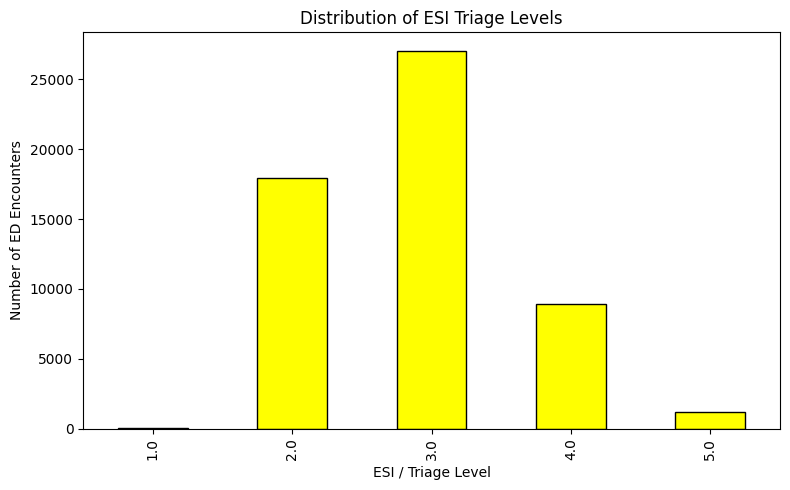

In [21]:
plt.figure(figsize=(8, 5))
esi_counts.plot(kind="bar", color='yellow', edgecolor='black')
plt.xlabel("ESI / Triage Level")
plt.ylabel("Number of ED Encounters")
plt.title("Distribution of ESI Triage Levels")
plt.tight_layout()
plt.savefig(DOCS_PATH / "week5_esi_distribution.png", dpi=300)
plt.show()

###LINE GRAPH: ADMISSION RATE BY ESI LEVEL

In [23]:
'''Calculate the average admission outcome for each ESI level.
If the 'disposition' column is coded as Admit/Discharge, the mean represents
the admission rate for each triage group'''

# Check the disposition categories before creating the flag
print("Disposition categories:")
print(df["disposition"].value_counts(dropna=False))

# Create a binary admission flag:
# Admit = 1, Discharge = 0
df["admitted_flag"] = (df["disposition"] == "Admit").astype(int)

# Calculate the admission rate for each ESI level.
# Because admitted_flag is 0/1, the mean equals the proportion admitted.
admission_by_esi = (
    df.groupby("esi")["admitted_flag"]
    .mean()
    .reset_index()
    .sort_values("esi")
)

# Convert the admission rate to a percentage for easier interpretation.
admission_by_esi["admission_rate_percent"] = admission_by_esi["admitted_flag"] * 100

# Display the table used to create the line graph.
admission_by_esi

Disposition categories:
disposition
Discharge    34565
Admit        20556
Name: count, dtype: int64


,esi,admitted_flag,admission_rate_percent
0,1.0,0.883117,88.311688
1,2.0,0.608179,60.817898
2,3.0,0.342910,34.291003
3,4.0,0.034735,3.473471
4,5.0,0.013180,1.317957


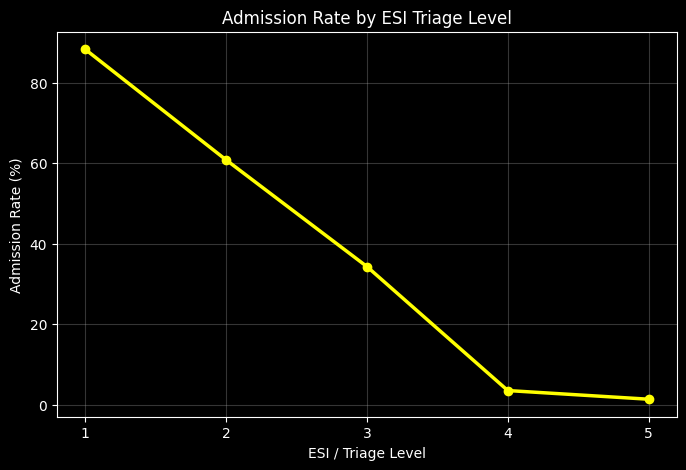

In [33]:
#Create the line graph showing how admission rate changes by ESI level.
fig, ax = plt.subplots(figsize=(8, 5), facecolor="black")

ax.plot(
    admission_by_esi["esi"],
    admission_by_esi["admission_rate_percent"],
    marker="o",
    color="yellow",
    linewidth=2.5
)
# Set the inside plot area background
ax.set_facecolor("black")

#Labels and title
ax.set_xlabel("ESI / Triage Level", color="white")
ax.set_ylabel("Admission Rate (%)", color="white")
ax.set_title("Admission Rate by ESI Triage Level", color="white")

#Make labels white so they are visible on the dark background
ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

#Set x-axis ticks to the ESI levels
ax.set_xticks(admission_by_esi["esi"])

#Add a subtle grid
ax.grid(True, alpha=0.3)

#Make the border/spines white
for spine in ax.spines.values():
    spine.set_color("white")

#Save the line graph as a final Week 5 artefact in the docs folder.
plt.savefig("week5_admission_rate_by_esi_line.png", dpi=300)
plt.show()

## 4. Missingness profile

This initial pass checks missing values across all columns.

***A 0% missingness result does not automatically mean the data is perfect; implausible values and coding issues still need clinical review.***

In [34]:
#Calculate exact missingness for every feature in the dataset.
#This produces the numerical values behind the missingness visualisation.
missing = (
    df.isna()
    .sum()
    .reset_index()
)

#Rename the columns so the table is easy to read.
missing.columns = ["feature", "missing_count"]

#convert the missing counts into percentages of the full dataset
missing["missing_percent"] = (missing["missing_count"] / len(df) * 100).round(2)
missing = missing.sort_values(["missing_percent", "missing_count"], ascending=False)

missing.head(25)

,feature,missing_count,missing_percent
0,Unnamed: 0,0,0.0
1,dep_name,0,0.0
2,esi,0,0.0
3,age,0,0.0
4,gender,0,0.0
5,ethnicity,0,0.0
6,race,0,0.0
7,lang,0,0.0
8,religion,0,0.0
9,maritalstatus,0,0.0


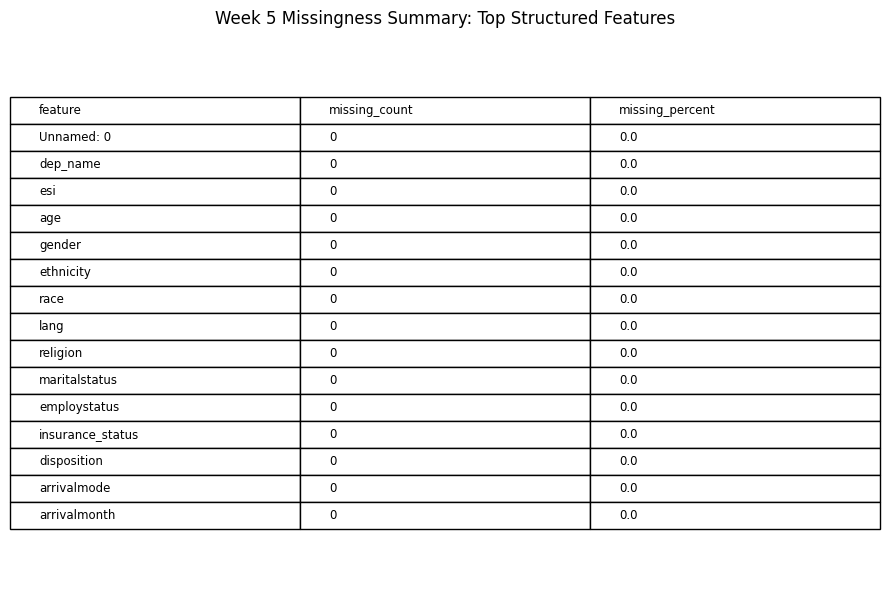

In [43]:
#Storing the missingness table as a csv
missing.to_csv("week5_missingness_table.csv", index=False)

top_missing = missing[missing["feature"].isin(structured)].head(15)
#Outputting Missingness values as a table figure
fig, ax = plt.subplots(figsize=(9, 6))
ax.axis("off")
table = ax.table(
    cellText=top_missing.values,
    colLabels=top_missing.columns,
    loc="center",
    cellLoc="left",
    colLoc="left"
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.4)
ax.set_title("Week 5 Missingness Summary: Top Structured Features", pad=16)
plt.tight_layout()
plt.savefig("week5_missingness_summary.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Demographic and fairness-sensitive variables

Race, ethnicity, gender, and insurance status should be treated carefully because they may reflect access, social, and system-level patterns rather than purely clinical risk.

In [36]:
#Counting the frequency by demographic category and outputting as separate tables for easy analysis

for col in ["gender", "race", "ethnicity", "insurance_status", "arrivalmode", "disposition"]:
    print(f"\n{col}")

     #Show the ten most common categories, including missing values
    display(df[col].value_counts(dropna=False).head(10))



gender


,count
gender,
Female,31744
Male,23377



race


,count
race,
White or Caucasian,29435
Black or African American,15963
Other,9016
Patient Refused,370
Asian,175
Unknown,76
American Indian or Alaska Native,66
Native Hawaiian or Other Pacific Islander,20



ethnicity


...

,count
insurance_status,
Medicaid,21427
Medicare,17581
Commercial,14056
Other,1883
Self pay,174



arrivalmode


,count
arrivalmode,
Car,22797
ambulance,18561
Walk-in,12598
Other,540
Public Transportation,350
Wheelchair,267
Police,8



disposition


,count
disposition,
Discharge,34565
Admit,20556


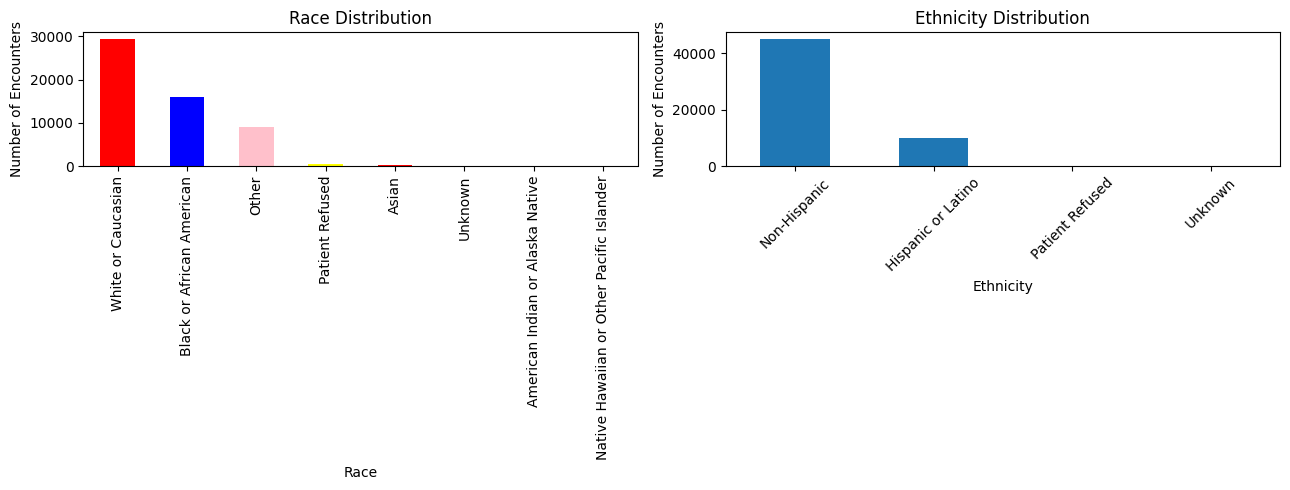

In [37]:
'''Create side-by-side bar charts for race and ethnicity distributions.
These charts support the fairness discussion in the feasibility memo'''
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['red', 'blue', 'pink', 'yellow']

#Plotting the ten most frequent race categories
df["race"].value_counts(dropna=False).head(10).plot(kind="bar", ax=axes[0], color=colors)
axes[0].set_title("Race Distribution")
axes[0].set_xlabel("Race")
axes[0].set_ylabel("Number of Encounters")
axes[0].tick_params(axis="x", rotation=90)

#Visualizing the most frequent ethnicity categories
df["ethnicity"].value_counts(dropna=False).head(10).plot(kind="bar", ax=axes[1])
axes[1].set_title("Ethnicity Distribution")
axes[1].set_xlabel("Ethnicity")
axes[1].set_ylabel("Number of Encounters")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("week5_race_ethnicity_distribution.png", dpi=300)
plt.show()

## 6. Chief complaint distribution

The dataset contains many binary chief complaint flags. These features are clinically useful, but many may be sparse.


In [38]:
#Calculating the sum of the chief complaint flags to find out how often each complaint appears.
#Because these are one-hot columns, summing the column gives the number of encounters with that complaint.
cc_counts = df[cc_flags].sum().sort_values(ascending=False)

#Display the 20 most common chief complaint flags.
cc_counts.head(20)

,0
cc_abdominalpain,6717.0
cc_other,4491.0
cc_chestpain,3712.0
cc_shortnessofbreath,3098.0
cc_backpain,1997.0
cc_fall,1926.0
cc_cough,1439.0
cc_dizziness,1292.0
cc_legpain,1264.0
cc_emesis,1249.0


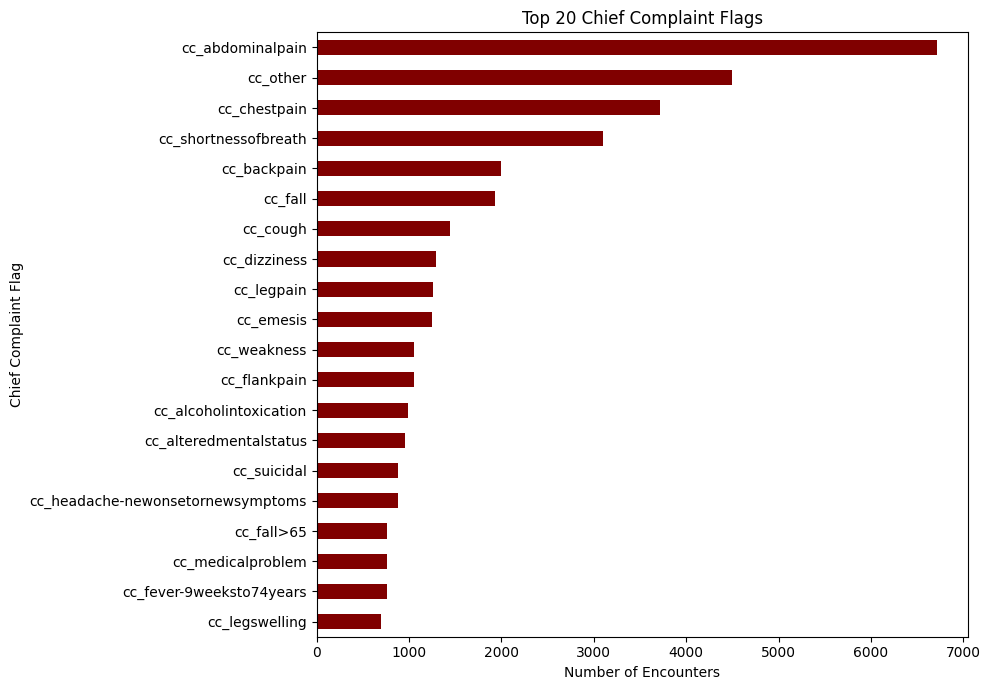

In [39]:
#Using a horizontal bar chart for the chief complaint bar chart

plt.figure(figsize=(10, 7))
cc_counts.head(20).plot(kind="barh", color= "maroon")
plt.xlabel("Number of Encounters")
plt.ylabel("Chief Complaint Flag")
plt.title("Top 20 Chief Complaint Flags")
plt.gca().invert_yaxis()
plt.tight_layout()

#Saving the generated png for analysis
plt.savefig("week5_top_chief_complaints.png", dpi=300)
plt.show()

## 7. Vitals and clinical plausibility checks

These checks use conservative review ranges to identify values that may need clinical review before modelling. Values outside the range are not automatically wrong, but they should be documented.

In [40]:
#Select the main triage-time vital signs and clinical measurements.
vitals = [
    "age",
    "triage_vital_hr",
    "triage_vital_sbp",
    "triage_vital_dbp",
    "triage_vital_rr",
    "triage_vital_o2",
    "triage_vital_temp",
    "triage_glucose",
]


#Generate descriptive statistics for the triage vital-sign features.

'''This helps check the typical range, spread, and possible outliers for key clinical inputs
such as heart rate, blood pressure, respiratory rate, oxygen saturation, temperature, and glucose.'''
df[vitals].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,55121.0,55.32,19.54,18.0,40.0,55.0,70.0,107.0
triage_vital_hr,55121.0,86.45,16.96,32.0,74.0,85.0,97.0,221.0
triage_vital_sbp,55121.0,133.68,22.65,53.0,118.0,132.0,147.0,266.0
triage_vital_dbp,55121.0,79.53,14.59,27.0,70.0,79.0,89.0,189.0
triage_vital_rr,55121.0,17.84,2.07,8.0,16.0,18.0,18.0,66.0
triage_vital_o2,55121.0,97.02,2.08,62.0,96.0,98.0,98.0,99.0
triage_vital_temp,55121.0,98.09,0.81,91.5,97.7,98.0,98.4,106.0
triage_glucose,55121.0,130.09,73.66,16.0,93.0,107.0,134.0,1066.0


In [41]:
#Defining the plausibility ranges to identify outliers

PLAUSIBLE = {
    "age": (0, 120),
    "esi": (1, 5),
    "triage_vital_hr": (40, 180),
    "triage_vital_sbp": (70, 250),
    "triage_vital_dbp": (30, 150),
    "triage_vital_rr": (8, 40),
    "triage_vital_o2": (70, 100),
    "triage_vital_temp": (94, 104),
    "triage_glucose": (40, 600),
}

#Storing one summary row per clinical feature.
outlier_rows = []

#Looping through each plausibility range and count values below and above the selected review limits.
for col, (low, high) in PLAUSIBLE.items():
    #converting to numeric defensively so that accidental string values become NaN instead of breaking the audit.
    numeric_col = pd.to_numeric(df[col], errors="coerce")

    #Appending the review counts for this feature
    outlier_rows.append({
        "feature": col,
        "plausible_low": low,
        "plausible_high": high,
        "below_range": int((numeric_col < low).sum()),
        "above_range": int((numeric_col > high).sum()),
        "missing_count": int(numeric_col.isna().sum())
    })

outlier_report = pd.DataFrame(outlier_rows)

#Adding a combined flag count to make ranking and plotting easier.
outlier_report["total_outside_range"] = outlier_report["below_range"] + outlier_report["above_range"]

outlier_report

,feature,plausible_low,plausible_high,below_range,above_range,missing_count,total_outside_range
0,age,0,120,0,0,0,0
1,esi,1,5,0,0,0,0
2,triage_vital_hr,40,180,21,11,0,32
3,triage_vital_sbp,70,250,45,5,0,50
4,triage_vital_dbp,30,150,7,21,0,28
5,triage_vital_rr,8,40,0,14,0,14
6,triage_vital_o2,70,100,7,0,0,7
7,triage_vital_temp,94,104,6,9,0,15
8,triage_glucose,40,600,26,164,0,190


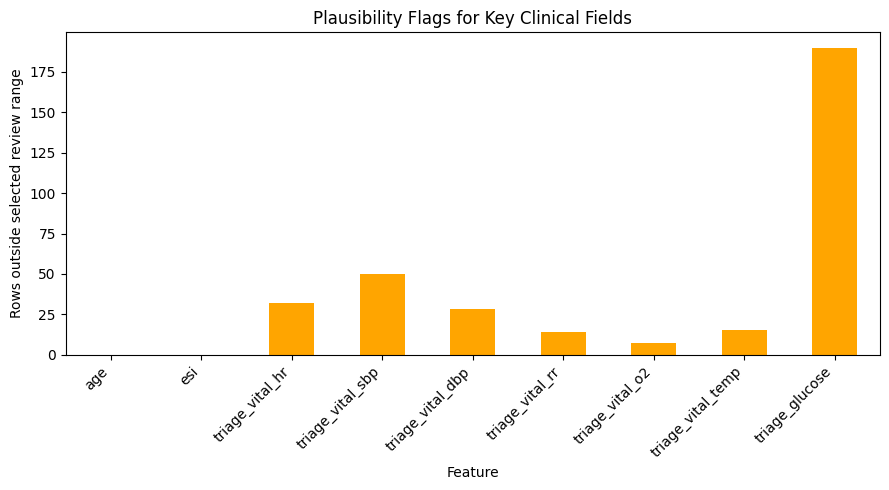

In [42]:
outlier_report.to_csv("week5_outlier_plausibility_report.csv", index=False)

#Plotting the number of values outside the selected clinical review range for each feature
plt.figure(figsize=(9, 5))
outlier_report.set_index("feature")["total_outside_range"].plot(kind="bar", color="orange")
plt.xlabel("Feature")
plt.ylabel("Rows outside selected review range")
plt.title("Plausibility Flags for Key Clinical Fields")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("week5_plausibility_flags.png", dpi=300)
plt.show()

## 8. Simple correlation with ESI

This is only an exploratory ranking. ESI is ordinal, so this notebook uses Spearman correlation as a simple first pass. Clinical reasoning should still guide the final shortlist.

### Simple Correlation method:

The notebook first uses the default Pearson correlation as a simple exploratory check, similar to the general correlation approach used in the tutorial. Because ESI is an ordinal triage score, where ESI 1 is highest acuity and ESI 5 is lowest acuity, I also calculated Spearman correlation as an exploratory extension. From my research for this submission I've learned that Pearson checks linear numeric association, while Spearman checks whether features tend to increase or decrease with the ordered ESI levels. These results are not final feature importance scores; they are only used to support the first-pass feature shortlist alongside clinical reasoning

In [45]:
#Select numeric columns only because correlation requires numeric input.
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

#Taking out the flag column I added.
candidate_cols = [
    c for c in numeric_cols if c!="admitted_flag"
    if c not in ["esi", "Unnamed: 0"]
]

#Calculating the Pearson correlation as an initial linear association check.
pearson_corr = (
    df[candidate_cols + [TARGET]]
    .corr(method="pearson")[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)

pearson_corr.head(20)

,esi
age,-0.236582
triage_vital_o2_device,-0.208956
triage_vital_o2,0.177859
cc_chestpain,-0.164328
cc_shortnessofbreath,-0.150285
cc_suicidal,-0.142603
cc_backpain,0.142140
cc_alcoholintoxication,-0.142127
cc_rash,0.133698
cc_alteredmentalstatus,-0.131958


In [47]:
#Spearman Correlation with ESI levels

'''Spearman is useful here because ESI is ordinal rather than a continuous measurement'''
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
candidate_cols = [c for c in numeric_cols if c not in ["esi", "Unnamed: 0","admitted_flag"]]

#ranking the features by absolute Spearman correlation with the triage level.
corr = (
    df[candidate_cols + [TARGET]]
    .corr(method="spearman")[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)

corr.head(20)

,esi
age,-0.238160
triage_vital_o2_device,-0.219227
cc_chestpain,-0.168764
triage_vital_o2,0.158817
cc_shortnessofbreath,-0.154545
cc_suicidal,-0.154502
cc_alcoholintoxication,-0.154228
cc_backpain,0.145113
cc_alteredmentalstatus,-0.141295
cc_kneepain,0.117486


## 8. Interim feature shortlist

This shortlist combines simple correlation with clinical intuition. It will be refined for the final memo.

In [48]:
#Creating a top 10 feature shortlist using both exploratory correlation results and clinical reasoning.
'''Features ranked highly if they showed a simple association with ESI and/or are standard triage indicators
#that clinicians use to assess acuity at ED arrival.'''

feature_shortlist = pd.DataFrame([
    (1, "age", "Older patients may have less physiological reserve and showed the strongest simple association with ESI."),
    (2, "triage_vital_o2_device", "Use of an oxygen device suggests respiratory support needs and was strongly associated with higher acuity."),
    (3, "cc_chestpain", "Chest pain is a high-risk ED presentation because it may indicate acute coronary syndrome or other cardiac emergencies."),
    (4, "triage_vital_o2", "Low oxygen saturation directly reflects respiratory compromise."),
    (5, "cc_shortnessofbreath", "Shortness of breath may indicate respiratory or cardiac deterioration."),
    (6, "cc_alteredmentalstatus", "Altered mental status can reflect neurologic, metabolic, septic, or toxicologic emergencies."),
    (7, "triage_glucose", "Extremely low or high glucose can require urgent intervention."),
    (8, "triage_vital_sbp", "Systolic blood pressure helps flag shock, bleeding, dehydration, or severe cardiovascular stress."),
    (9, "triage_vital_hr", "Heart rate reflects pain, fever, anxiety, shock, arrhythmia, or physiologic stress."),
    (10, "triage_vital_rr", "Respiratory rate is an early warning sign for clinical deterioration.")
], columns=["rank", "feature", "one_sentence_reason"])

feature_shortlist.to_csv("week5_top10_feature_shortlist.csv", index=False)
feature_shortlist

,rank,feature,one_sentence_reason
0,1,age,Older patients may have less physiological res...
1,2,triage_vital_o2_device,Use of an oxygen device suggests respiratory s...
2,3,cc_chestpain,Chest pain is a high-risk ED presentation beca...
3,4,triage_vital_o2,Low oxygen saturation directly reflects respir...
4,5,cc_shortnessofbreath,Shortness of breath may indicate respiratory o...
5,6,cc_alteredmentalstatus,"Altered mental status can reflect neurologic, ..."
6,7,triage_glucose,Extremely low or high glucose can require urge...
7,8,triage_vital_sbp,"Systolic blood pressure helps flag shock, blee..."
8,9,triage_vital_hr,"Heart rate reflects pain, fever, anxiety, shoc..."
9,10,triage_vital_rr,Respiratory rate is an early warning sign for ...


## 9. Early feasibility notes

Initial verdict: The dataset has useful triage-time variables and a complete ESI target but the final memo should discuss the class imbalance within the ESI level values, sparse complaint flags, clinical plausibility flags, fairness sensitive variables, and exclusion of disposition to avoid leakage.